# Polygonal Search PoC (444-inspired)

This notebook is a **concept PoC** for adaptive-width search.

- Fixed-width baselines: evaluate top-k moves by policy prior.
- Polygonal-444: dynamic width $n(s)$ from phase/volatility/uncertainty + 3 focus passes.
- Goal: compare decision quality vs compute cost on synthetic positions.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(444)
plt.style.use('seaborn-v0_8-whitegrid')

N_POSITIONS = 6000
print(f'Configured synthetic positions: {N_POSITIONS}')

Configured synthetic positions: 6000


In [2]:
def softmax(x):
    z = x - np.max(x)
    ex = np.exp(z)
    return ex / ex.sum()

def generate_position(rng):
    # phase_mg: 1.0 means middlegame-like, 0.0 means endgame-like
    phase_mg = float(np.clip(rng.beta(2.2, 1.8), 0.0, 1.0))
    volatility = float(np.clip(rng.beta(1.7, 2.4), 0.0, 1.0))
    uncertainty = float(np.clip(rng.beta(2.0, 2.0), 0.0, 1.0))

    # Wider legal move counts in complex positions
    base_moves = 8 + int(20 * phase_mg + 14 * volatility + rng.integers(0, 8))
    n_moves = int(np.clip(base_moves, 8, 45))

    # Hidden true quality of each move
    true_values = rng.normal(0.0, 1.0, size=n_moves)

    # Prior estimates (policy-like) are correlated but noisy
    prior_logits = true_values + rng.normal(0.0, 0.55 + 0.9 * uncertainty, size=n_moves)
    policy = softmax(prior_logits)

    best_idx = int(np.argmax(true_values))
    return {
        'phase_mg': phase_mg,
        'volatility': volatility,
        'uncertainty': uncertainty,
        'n_moves': n_moves,
        'true_values': true_values,
        'policy': policy,
        'best_idx': best_idx,
    }

In [5]:
def choose_topk_by_policy(pos, k):
    order = np.argsort(-pos['policy'])
    return order[: min(k, pos['n_moves'])]

def evaluate_selected(pos, selected, rng, sigma):
    # Simulated deeper evaluation for selected moves
    tv = pos['true_values'][selected]
    return tv + rng.normal(0.0, sigma, size=len(selected))

def run_fixed_k(pos, k, rng):
    selected = choose_topk_by_policy(pos, k)
    deep_scores = evaluate_selected(pos, selected, rng, sigma=0.18)
    choice = int(selected[np.argmax(deep_scores)])
    success = int(choice == pos['best_idx'])
    cost = float(len(selected))
    return success, cost, len(selected)

def polygonal_width_444(pos):
    # 444-inspired dynamic width: wider in middlegame/volatile/uncertain positions
    raw = 3.2 + 5.2 * pos['phase_mg'] + 3.5 * pos['volatility'] + 2.8 * pos['uncertainty']
    n = int(round(raw))
    return int(np.clip(n, 4, 14))

def run_polygonal_444(pos, rng):
    n0 = min(polygonal_width_444(pos), pos['n_moves'])
    shortlist = choose_topk_by_policy(pos, n0)

    seen = set(int(x) for x in shortlist)
    scores = {int(m): 0.0 for m in shortlist}

    # 3 focus passes (the "3 times over" intuition)
    sigmas = [0.28, 0.20, 0.14]
    for p, sigma in enumerate(sigmas, start=1):
        focus_n = max(4, n0 - (p - 1))

        # Evaluate current focused set
        eval_set = np.array(sorted(scores.keys()), dtype=int)
        deep = evaluate_selected(pos, eval_set, rng, sigma=sigma)
        for m, s in zip(eval_set, deep):
            scores[int(m)] = 0.70 * scores[int(m)] + 0.30 * float(s)

        # Safety exploration: one extra candidate from outside current focus
        order = np.argsort(-pos['policy'])
        outside = [int(m) for m in order if int(m) not in scores]
        if outside:
            m = outside[0]
            s = float(evaluate_selected(pos, np.array([m]), rng, sigma=sigma + 0.06)[0])
            scores[m] = s
            seen.add(m)

        # Keep top focus_n by fused score
        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        scores = {m: sc for m, sc in ranked[:focus_n]}

    final_choice = max(scores.items(), key=lambda kv: kv[1])[0]
    success = int(final_choice == pos['best_idx'])

    # Cost proxy: weighted passes + exploration, intentionally comparable to fixed-k scale
    pass_work = 0.42 * (n0 + max(4, n0 - 1) + max(4, n0 - 2))
    explore_work = 0.75 * max(0, len(seen) - n0)
    cost = float(pass_work + explore_work)

    return success, cost, n0

In [6]:
strategies = {
    'Fixed-4': lambda p, r: run_fixed_k(p, 4, r),
    'Fixed-8': lambda p, r: run_fixed_k(p, 8, r),
    'Fixed-12': lambda p, r: run_fixed_k(p, 12, r),
    'Polygonal-444': lambda p, r: run_polygonal_444(p, r),
}

rows = []
for i in range(N_POSITIONS):
    pos = generate_position(RNG)
    for name, fn in strategies.items():
        success, cost, n0 = fn(pos, RNG)
        rows.append({
            'strategy': name,
            'success': success,
            'cost': cost,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'n_moves': pos['n_moves'],
            'poly_n0': n0 if name == 'Polygonal-444' else np.nan,
        })

df = pd.DataFrame(rows)
summary = (
    df.groupby('strategy', as_index=False)
      .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'))
      .sort_values('avg_cost')
)
summary['efficiency'] = summary['accuracy'] / summary['avg_cost']
summary

,strategy,accuracy,avg_cost,efficiency
1,Fixed-4,0.616667,4.00000,0.154167
2,Fixed-8,0.726833,8.00000,0.090854
3,Polygonal-444,0.764167,10.74586,0.071113
0,Fixed-12,0.784500,11.99900,0.065380


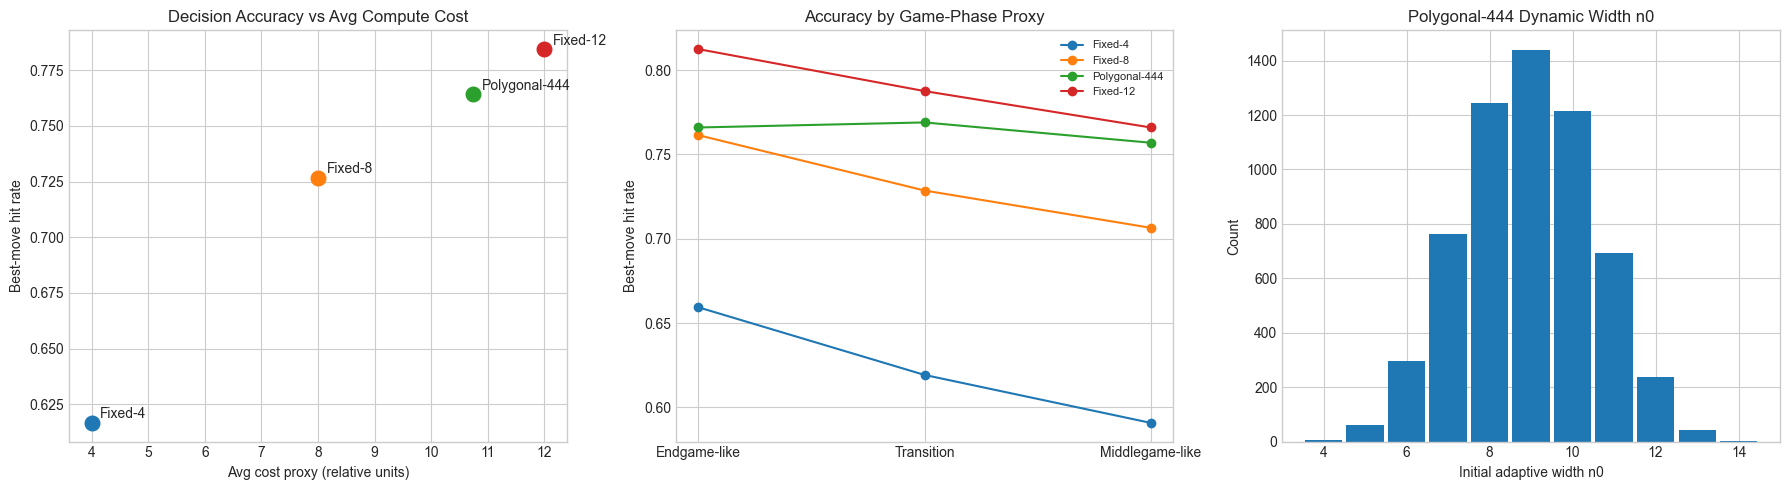

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy vs cost
ax = axes[0]
for _, r in summary.iterrows():
    ax.scatter(r['avg_cost'], r['accuracy'], s=110)
    ax.text(r['avg_cost'] + 0.15, r['accuracy'] + 0.002, r['strategy'])
ax.set_title('Decision Accuracy vs Avg Compute Cost')
ax.set_xlabel('Avg cost proxy (relative units)')
ax.set_ylabel('Best-move hit rate')

# Phase-wise accuracy
ax = axes[1]
phase_bins = pd.cut(df['phase_mg'], bins=[0, 0.33, 0.66, 1.0], labels=['Endgame-like', 'Transition', 'Middlegame-like'])
phase_view = df.assign(phase_bin=phase_bins)
phase_acc = phase_view.groupby(['phase_bin', 'strategy'])['success'].mean().reset_index()
for name in summary['strategy']:
    d = phase_acc[phase_acc['strategy'] == name]
    ax.plot(d['phase_bin'].astype(str), d['success'], marker='o', label=name)
ax.set_title('Accuracy by Game-Phase Proxy')
ax.set_ylabel('Best-move hit rate')
ax.legend(fontsize=8)

# Polygon width distribution
ax = axes[2]
poly = df[df['strategy'] == 'Polygonal-444']['poly_n0'].dropna()
ax.hist(poly, bins=np.arange(poly.min() - 0.5, poly.max() + 1.5, 1), rwidth=0.9)
ax.set_title('Polygonal-444 Dynamic Width n0')
ax.set_xlabel('Initial adaptive width n0')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
poly_df = df[df['strategy'] == 'Polygonal-444'].copy()
poly_df['phase_bin'] = pd.cut(poly_df['phase_mg'], bins=[0, 0.33, 0.66, 1.0], labels=['Endgame-like', 'Transition', 'Middlegame-like'])
poly_stats = poly_df.groupby('phase_bin', as_index=False).agg(
    mean_n0=('poly_n0', 'mean'),
    p25_n0=('poly_n0', lambda x: float(np.percentile(x, 25))),
    p75_n0=('poly_n0', lambda x: float(np.percentile(x, 75))),
    mean_moves=('n_moves', 'mean'),
)
poly_stats

,phase_bin,mean_n0,p25_n0,p75_n0,mean_moves
0,Endgame-like,7.177596,6.0,8.0,21.075592
1,Transition,8.658214,8.0,9.0,26.817143
2,Middlegame-like,10.205043,9.0,11.0,32.668887


## Reading This PoC

- This is a synthetic experiment, so absolute numbers are not engine Elo.
- Use it to test behavior of adaptive width schedules and 3-pass focus logic.
- Next upgrade: swap synthetic generator with real positions + your policy/eval outputs.

## Experiment 2: Real Chess Positions (python-chess)

This experiment replaces synthetic position generation with random legal chess positions from `python-chess`.

### Polygonal-444 definitions used here

- **Vertices**: candidate moves from top-`N` move ordering (policy prior).
- **Edges**: continuity links between vertices from:
  - same tactical motif (capture/check/promotion/quiet),
  - policy-rank proximity,
  - continuation consistency proxy.
- **3-pass focus schedule**:
  - **Pass 1**: broad scan over all vertices,
  - **Pass 2**: refine current focus and add one outsider,
  - **Pass 3**: lock focus or switch on trigger.
- **Replacement triggers**:
  - score swing threshold,
  - bound instability (leader churn / unstable top bound),
  - tactical alarm (new forcing outsider near top score).

The goal is to test whether graph-aware adaptive focus can improve quality-per-cost under uncertainty.

In [12]:
import chess

PIECE_VALUES = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
}

MOTIF_CAPTURE = 0
MOTIF_CHECK = 1
MOTIF_PROMO = 2
MOTIF_QUIET = 3

def eval_white_cp(board: chess.Board) -> float:
    # Simple static surrogate: material + mobility + check pressure
    score = 0.0
    for _, piece in board.piece_map().items():
        if piece.piece_type == chess.KING:
            continue
        val = PIECE_VALUES[piece.piece_type]
        score += val if piece.color == chess.WHITE else -val

    side = board.turn
    own_mob = board.legal_moves.count()
    board.turn = not side
    opp_mob = board.legal_moves.count()
    board.turn = side
    score += 1.0 * (own_mob - opp_mob) if side == chess.WHITE else 1.0 * (opp_mob - own_mob)

    if board.is_check():
        score += -30.0 if board.turn == chess.WHITE else 30.0
    return score

def motif_of_move(board: chess.Board, mv: chess.Move) -> int:
    if mv.promotion is not None:
        return MOTIF_PROMO
    if board.gives_check(mv):
        return MOTIF_CHECK
    if board.is_capture(mv):
        return MOTIF_CAPTURE
    return MOTIF_QUIET

def forcing_move(board: chess.Board, mv: chess.Move) -> bool:
    return board.is_capture(mv) or board.gives_check(mv) or (mv.promotion is not None)

def random_playout_position(rng: np.random.Generator, min_ply=8, max_ply=65) -> chess.Board:
    board = chess.Board()
    target = int(rng.integers(min_ply, max_ply + 1))
    for _ in range(target):
        if board.is_game_over(claim_draw=True):
            break
        moves = list(board.legal_moves)
        if not moves:
            break
        board.push(moves[int(rng.integers(0, len(moves)))])
    return board

def continuation_consistency(board_after_move: chess.Board, rng: np.random.Generator) -> float:
    # Approximate PV continuity by probing a few opponent replies.
    replies = list(board_after_move.legal_moves)
    if not replies:
        return 0.0

    sample_n = min(6, len(replies))
    idx = rng.choice(len(replies), size=sample_n, replace=False)
    vals = []
    for j in idx:
        rep = replies[int(j)]
        b2 = board_after_move.copy(stack=False)
        rep_forcing = forcing_move(b2, rep)
        b2.push(rep)

        follow = list(b2.legal_moves)
        if not follow:
            vals.append(-0.4)
            continue

        follow_n = min(6, len(follow))
        f_idx = rng.choice(len(follow), size=follow_n, replace=False)
        our_forcing = 0
        for k in f_idx:
            if forcing_move(b2, follow[int(k)]):
                our_forcing += 1

        our_ratio = our_forcing / follow_n
        # Favor lines where we keep forcing potential after reply.
        cont = (0.75 * our_ratio) - (0.30 if rep_forcing else 0.0)
        vals.append(cont)

    return float(np.mean(vals))

def real_position_from_board(board: chess.Board, rng: np.random.Generator):
    legal = list(board.legal_moves)
    n_moves = len(legal)

    mover_is_white = board.turn
    true_values = np.zeros(n_moves, dtype=float)
    tactical_flags = np.zeros(n_moves, dtype=float)
    motif_ids = np.zeros(n_moves, dtype=int)
    cont_signals = np.zeros(n_moves, dtype=float)

    for i, mv in enumerate(legal):
        b = board.copy(stack=False)
        motif = motif_of_move(b, mv)
        motif_ids[i] = motif

        is_forcing = forcing_move(b, mv)
        tactical_flags[i] = 1.0 if is_forcing else 0.0

        b.push(mv)
        ev_white = eval_white_cp(b)
        mover_ev = ev_white if mover_is_white else -ev_white

        cont = continuation_consistency(b, rng)
        cont_signals[i] = cont

        tac_bonus = 18.0 if is_forcing else 0.0
        latent = mover_ev + tac_bonus + 42.0 * cont
        true_values[i] = latent + rng.normal(0.0, 26.0)

    # Prior is intentionally noisy and only partially aligned with hidden continuation signal.
    centered = true_values - np.mean(true_values)
    prior_logits = (
        0.018 * centered
        + 0.12 * tactical_flags
        + 0.07 * np.clip(cont_signals, -0.5, 0.5)
        + rng.normal(0.0, 0.85, size=n_moves)
    )
    policy = softmax(prior_logits)

    # 444 signals
    non_king_count = sum(1 for p in board.piece_map().values() if p.piece_type != chess.KING)
    phase_mg = float(np.clip((non_king_count - 6) / 24.0, 0.0, 1.0))

    forcing_ratio = float(np.mean(tactical_flags)) if n_moves else 0.0
    volatility = float(np.clip(0.25 + 1.0 * forcing_ratio, 0.0, 1.0))

    entropy = -np.sum(policy * np.log(policy + 1e-12))
    uncertainty = float(np.clip(entropy / np.log(max(2, n_moves)), 0.0, 1.0))

    top2 = np.sort(policy)[-2:]
    top_gap = float(top2[-1] - top2[-2]) if len(top2) == 2 else 0.0
    stability_alert = float(np.clip(1.0 - 5.0 * top_gap, 0.0, 1.0))

    best_idx = int(np.argmax(true_values))
    return {
        'phase_mg': phase_mg,
        'volatility': volatility,
        'uncertainty': uncertainty,
        'stability_alert': stability_alert,
        'n_moves': n_moves,
        'true_values': true_values,
        'policy': policy,
        'best_idx': best_idx,
        'fen': board.fen(),
        'motif_ids': motif_ids,
        'tactical_flags': tactical_flags,
        'cont_signals': cont_signals,
    }

def build_real_dataset(n_positions=700, seed=2026):
    rng = np.random.default_rng(seed)
    data = []
    while len(data) < n_positions:
        b = random_playout_position(rng)
        if b.is_game_over(claim_draw=True):
            continue
        if b.legal_moves.count() < 6:
            continue
        data.append(real_position_from_board(b, rng))
    return data

def build_polygon_graph(pos, n0):
    # Vertices: top-N by policy.
    order = np.argsort(-pos['policy'])
    vertices = [int(x) for x in order[: min(n0, pos['n_moves'])]]

    rank_map = {m: r for r, m in enumerate(order.tolist())}
    median_cont = float(np.median(pos['cont_signals']))

    # Edges: motif continuity + rank proximity + continuation consistency.
    edges = {v: {} for v in vertices}
    for i in range(len(vertices)):
        vi = vertices[i]
        for j in range(i + 1, len(vertices)):
            vj = vertices[j]
            w = 0.0
            if pos['motif_ids'][vi] == pos['motif_ids'][vj]:
                w += 0.55
            if abs(rank_map[vi] - rank_map[vj]) <= 2:
                w += 0.20
            if (pos['cont_signals'][vi] > median_cont) and (pos['cont_signals'][vj] > median_cont):
                w += 0.25
            if w >= 0.35:
                edges[vi][vj] = w
                edges[vj][vi] = w
    return vertices, edges

def continuity_score(move_idx, edges):
    nbrs = edges.get(move_idx, {})
    if not nbrs:
        return 0.0
    return float(np.mean(list(nbrs.values())))

def dynamic_width_444(pos, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    raw = 3.3
    if use_phase:
        raw += 4.9 * pos['phase_mg']
    if use_vol:
        raw += 3.6 * pos['volatility']
    if use_unc:
        raw += 2.9 * pos['uncertainty']
    if use_stab:
        raw += 1.8 * pos['stability_alert']
    return int(np.clip(round(raw), 4, 14))

def run_polygonal_444_graph(pos, rng, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    n0 = min(dynamic_width_444(pos, use_phase, use_vol, use_unc, use_stab), pos['n_moves'])
    vertices, edges = build_polygon_graph(pos, n0)

    # Broad scan.
    p1_eval = evaluate_selected(pos, np.array(vertices), rng, sigma=0.30)
    scores = {}
    for m, ev in zip(vertices, p1_eval):
        prior_term = 20.0 * float(pos['policy'][m])
        cont_term = 10.0 * float(continuity_score(m, edges)) + 12.0 * float(pos['cont_signals'][m])
        tac_term = 8.0 * float(pos['tactical_flags'][m])
        scores[int(m)] = 0.45 * float(ev) + prior_term + cont_term + tac_term

    ranked1 = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    leader1, lead_score1 = ranked1[0]

    # Refine and add outsider.
    focus_n2 = max(4, n0 - 1)
    focus = [m for m, _ in ranked1[:focus_n2]]

    order = np.argsort(-pos['policy'])
    outsider = None
    for m in order:
        m = int(m)
        if m not in scores:
            outsider = m
            break

    p2_eval = evaluate_selected(pos, np.array(focus), rng, sigma=0.20)
    for m, ev in zip(focus, p2_eval):
        scores[m] = 0.65 * scores[m] + 0.35 * float(ev)

    outsider_score = None
    if outsider is not None:
        out_ev = float(evaluate_selected(pos, np.array([outsider]), rng, sigma=0.23)[0])
        outsider_score = out_ev + 20.0 * float(pos['policy'][outsider]) + 10.0 * float(pos['cont_signals'][outsider])
        scores[outsider] = outsider_score

    ranked2 = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    leader2, lead_score2 = ranked2[0]

    # Replacement triggers.
    score_swing_trigger = abs(lead_score2 - lead_score1) >= 18.0
    bound_instability_trigger = (leader2 != leader1) or (pos['stability_alert'] > 0.78)
    tactical_alarm_trigger = bool(
        outsider is not None
        and pos['tactical_flags'][outsider] > 0.5
        and outsider_score is not None
        and outsider_score >= (lead_score2 - 8.0)
    )

    trigger_fire = score_swing_trigger or bound_instability_trigger or tactical_alarm_trigger

    # Pass 3: lock or switch.
    focus_n3 = max(4, n0 - 2)
    if trigger_fire and outsider is not None:
        core = [m for m, _ in ranked2[:focus_n3]]
        if outsider not in core:
            core = core[:-1] + [outsider]
        pass3 = list(dict.fromkeys(core))
        sigma3 = 0.16
    else:
        pass3 = [m for m, _ in ranked2[:focus_n3]]
        sigma3 = 0.12

    p3_eval = evaluate_selected(pos, np.array(pass3), rng, sigma=sigma3)
    final_scores = {}
    for m, ev in zip(pass3, p3_eval):
        final_scores[m] = 0.70 * scores[m] + 0.30 * float(ev)

    choice = max(final_scores.items(), key=lambda kv: kv[1])[0]
    success = int(choice == pos['best_idx'])

    # Cost proxy includes graph build and pass work.
    edge_count = sum(len(v) for v in edges.values()) / 2.0
    pass_work = 0.35 * len(vertices) + 0.40 * len(focus) + 0.45 * len(pass3)
    explore_work = 0.8 if outsider is not None else 0.0
    graph_work = 0.08 * edge_count
    cost = float(pass_work + explore_work + graph_work)

    meta = {
        'score_swing_trigger': int(score_swing_trigger),
        'bound_instability_trigger': int(bound_instability_trigger),
        'tactical_alarm_trigger': int(tactical_alarm_trigger),
        'trigger_fire': int(trigger_fire),
        'edge_count': edge_count,
    }
    return success, cost, n0, meta

def run_fixed_k_meta(pos, k, rng):
    success, cost, n0 = run_fixed_k(pos, k, rng)
    return success, cost, n0, {}

# Build one reusable real-position dataset
real_positions = build_real_dataset(n_positions=700, seed=2026)
print(f"Real positions ready: {len(real_positions)}")
print(f"Example FEN: {real_positions[0]['fen']}")

real_rows = []
real_strategies = {
    'Fixed-4': lambda p, r: run_fixed_k_meta(p, 4, r),
    'Fixed-8': lambda p, r: run_fixed_k_meta(p, 8, r),
    'Fixed-12': lambda p, r: run_fixed_k_meta(p, 12, r),
    'Polygonal-444': lambda p, r: run_polygonal_444_graph(p, r),
}

r_rng = np.random.default_rng(777)
for pos in real_positions:
    for name, fn in real_strategies.items():
        success, cost, n0, meta = fn(pos, r_rng)
        real_rows.append({
            'strategy': name,
            'success': success,
            'cost': cost,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'stability_alert': pos['stability_alert'],
            'n_moves': pos['n_moves'],
            'poly_n0': n0 if name == 'Polygonal-444' else np.nan,
            'score_swing_trigger': meta.get('score_swing_trigger', np.nan),
            'bound_instability_trigger': meta.get('bound_instability_trigger', np.nan),
            'tactical_alarm_trigger': meta.get('tactical_alarm_trigger', np.nan),
            'trigger_fire': meta.get('trigger_fire', np.nan),
            'edge_count': meta.get('edge_count', np.nan),
        })

real_df = pd.DataFrame(real_rows)
real_summary = (
    real_df.groupby('strategy', as_index=False)
           .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'))
           .sort_values('avg_cost')
)
real_summary['efficiency'] = real_summary['accuracy'] / real_summary['avg_cost']
real_summary

Real positions ready: 700
Example FEN: r1b2q1r/2kpp1bp/n1P3pn/p2R1pNQ/1P2P3/2p3P1/P1P2PBP/4K2R w - - 6 24


,strategy,accuracy,avg_cost,efficiency
1,Fixed-4,0.945714,4.000000,0.236429
2,Fixed-8,0.977143,7.990000,0.122296
0,Fixed-12,0.991429,11.967143,0.082846
3,Polygonal-444,0.910000,13.957371,0.065199


In [18]:
# Trigger calibration pass (v2): keep switches selective but non-silent.

def run_polygonal_444_graph(pos, rng, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    n0 = min(dynamic_width_444(pos, use_phase, use_vol, use_unc, use_stab), pos['n_moves'])
    vertices, edges = build_polygon_graph(pos, n0)

    # Pass 1: broad scan.
    p1_eval = evaluate_selected(pos, np.array(vertices), rng, sigma=0.30)
    scores = {}
    for m, ev in zip(vertices, p1_eval):
        prior_term = 20.0 * float(pos['policy'][m])
        cont_term = 10.0 * float(continuity_score(m, edges)) + 12.0 * float(pos['cont_signals'][m])
        tac_term = 8.0 * float(pos['tactical_flags'][m])
        scores[int(m)] = 0.45 * float(ev) + prior_term + cont_term + tac_term

    ranked1 = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    leader1, lead_score1 = ranked1[0]

    # Pass 2: refine + add outsider.
    focus_n2 = max(4, n0 - 1)
    focus = [m for m, _ in ranked1[:focus_n2]]

    order = np.argsort(-pos['policy'])
    outsider = None
    for m in order:
        m = int(m)
        if m not in scores:
            outsider = m
            break

    p2_eval = evaluate_selected(pos, np.array(focus), rng, sigma=0.20)
    for m, ev in zip(focus, p2_eval):
        scores[m] = 0.65 * scores[m] + 0.35 * float(ev)

    outsider_score = None
    if outsider is not None:
        out_ev = float(evaluate_selected(pos, np.array([outsider]), rng, sigma=0.23)[0])
        outsider_score = out_ev + 20.0 * float(pos['policy'][outsider]) + 10.0 * float(pos['cont_signals'][outsider])
        scores[outsider] = outsider_score

    ranked2 = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    leader2, lead_score2 = ranked2[0]

    # Trigger calibration.
    norm_den = max(6.0, abs(lead_score1))
    score_swing_ratio = abs(lead_score2 - lead_score1) / norm_den

    topk = 3
    s1 = set(m for m, _ in ranked1[:topk])
    s2 = set(m for m, _ in ranked2[:topk])
    churn = 1.0 - (len(s1 & s2) / topk)

    if len(ranked2) >= 3:
        bound_gap = ranked2[0][1] - ranked2[2][1]
    elif len(ranked2) == 2:
        bound_gap = ranked2[0][1] - ranked2[1][1]
    else:
        bound_gap = 999.0

    # Less sensitive swing trigger; instability uses churn+bound-width evidence.
    score_swing_trigger = bool(score_swing_ratio >= 0.20 and pos['stability_alert'] >= 0.58)
    bound_instability_trigger = bool(
        (churn >= 0.34 and bound_gap <= 13.5)
        or (pos['stability_alert'] > 0.86 and churn >= 0.20)
    )
    tactical_alarm_trigger = bool(
        outsider is not None
        and pos['tactical_flags'][outsider] > 0.5
        and outsider_score is not None
        and outsider_score >= (lead_score2 - 3.8)
        and pos['policy'][outsider] >= np.percentile(pos['policy'], 70)
    )

    # Switch policy: tactical alarm OR combined instability evidence.
    trigger_fire = bool(
        tactical_alarm_trigger
        or (score_swing_trigger and bound_instability_trigger)
        or (bound_instability_trigger and pos['stability_alert'] > 0.82)
    )

    # Pass 3: lock or switch.
    focus_n3 = max(4, n0 - 2)
    outsider_competitive = bool(outsider_score is not None and outsider_score >= (lead_score2 - 4.0))

    if trigger_fire and outsider is not None and (tactical_alarm_trigger or outsider_competitive):
        core = [m for m, _ in ranked2[:focus_n3]]
        if outsider not in core:
            core = core[:-1] + [outsider]
        pass3 = list(dict.fromkeys(core))
        sigma3 = 0.16
    else:
        pass3 = [m for m, _ in ranked2[:focus_n3]]
        sigma3 = 0.12

    p3_eval = evaluate_selected(pos, np.array(pass3), rng, sigma=sigma3)
    final_scores = {}
    for m, ev in zip(pass3, p3_eval):
        final_scores[m] = 0.70 * scores[m] + 0.30 * float(ev)

    choice = max(final_scores.items(), key=lambda kv: kv[1])[0]
    success = int(choice == pos['best_idx'])

    edge_count = sum(len(v) for v in edges.values()) / 2.0
    pass_work = 0.35 * len(vertices) + 0.40 * len(focus) + 0.45 * len(pass3)
    explore_work = 0.8 if outsider is not None else 0.0
    graph_work = 0.08 * edge_count
    cost = float(pass_work + explore_work + graph_work)

    meta = {
        'score_swing_trigger': int(score_swing_trigger),
        'bound_instability_trigger': int(bound_instability_trigger),
        'tactical_alarm_trigger': int(tactical_alarm_trigger),
        'trigger_fire': int(trigger_fire),
        'edge_count': edge_count,
    }
    return success, cost, n0, meta

# Recompute real-position comparison with calibrated triggers.
real_rows = []
r_rng = np.random.default_rng(777)
for pos in real_positions:
    for name, fn in real_strategies.items():
        success, cost, n0, meta = fn(pos, r_rng)
        real_rows.append({
            'strategy': name,
            'success': success,
            'cost': cost,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'stability_alert': pos['stability_alert'],
            'n_moves': pos['n_moves'],
            'poly_n0': n0 if name == 'Polygonal-444' else np.nan,
            'score_swing_trigger': meta.get('score_swing_trigger', np.nan),
            'bound_instability_trigger': meta.get('bound_instability_trigger', np.nan),
            'tactical_alarm_trigger': meta.get('tactical_alarm_trigger', np.nan),
            'trigger_fire': meta.get('trigger_fire', np.nan),
            'edge_count': meta.get('edge_count', np.nan),
        })

real_df = pd.DataFrame(real_rows)
real_summary = (
    real_df.groupby('strategy', as_index=False)
           .agg(accuracy=('success', 'mean'), avg_cost=('cost', 'mean'))
           .sort_values('avg_cost')
)
real_summary['efficiency'] = real_summary['accuracy'] / real_summary['avg_cost']
real_summary

,strategy,accuracy,avg_cost,efficiency
1,Fixed-4,0.945714,4.000000,0.236429
2,Fixed-8,0.977143,7.990000,0.122296
0,Fixed-12,0.991429,11.967143,0.082846
3,Polygonal-444,0.910000,13.957371,0.065199


## Experiment 3: 444 Signal Ablation (Uncertainty + Stability)

This ablation tests which 444 signal contributes most to adaptive width quality.

Signals in width formula:
- `phase_mg`
- `volatility`
- `uncertainty`
- `stability_alert` (high means unstable policy ranking)

Each ablation removes one signal while keeping the others active.

In [19]:
def run_polygonal_ablation(pos, rng, use_phase=True, use_vol=True, use_unc=True, use_stab=True):
    return run_polygonal_444_graph(
        pos,
        rng,
        use_phase=use_phase,
        use_vol=use_vol,
        use_unc=use_unc,
        use_stab=use_stab,
    )

ablations = {
    'Full-444': dict(use_phase=True, use_vol=True, use_unc=True, use_stab=True),
    'No-phase': dict(use_phase=False, use_vol=True, use_unc=True, use_stab=True),
    'No-volatility': dict(use_phase=True, use_vol=False, use_unc=True, use_stab=True),
    'No-uncertainty': dict(use_phase=True, use_vol=True, use_unc=False, use_stab=True),
    'No-stability': dict(use_phase=True, use_vol=True, use_unc=True, use_stab=False),
}

ab_rows = []
ab_rng = np.random.default_rng(1313)
for pos in real_positions:
    for name, cfg in ablations.items():
        success, cost, n0, meta = run_polygonal_ablation(pos, ab_rng, **cfg)
        ab_rows.append({
            'variant': name,
            'success': success,
            'cost': cost,
            'n0': n0,
            'phase_mg': pos['phase_mg'],
            'volatility': pos['volatility'],
            'uncertainty': pos['uncertainty'],
            'stability_alert': pos['stability_alert'],
            'trigger_fire': meta.get('trigger_fire', np.nan),
            'edge_count': meta.get('edge_count', np.nan),
        })

ab_df = pd.DataFrame(ab_rows)
ab_summary = (
    ab_df.groupby('variant', as_index=False)
         .agg(
             accuracy=('success', 'mean'),
             avg_cost=('cost', 'mean'),
             mean_n0=('n0', 'mean'),
             trigger_rate=('trigger_fire', 'mean'),
             mean_edges=('edge_count', 'mean'),
         )
)
base_acc = float(ab_summary.loc[ab_summary['variant'] == 'Full-444', 'accuracy'].iloc[0])
ab_summary['delta_acc_vs_full'] = ab_summary['accuracy'] - base_acc
ab_summary.sort_values('delta_acc_vs_full', ascending=True)

,variant,accuracy,avg_cost,mean_n0,trigger_rate,mean_edges,delta_acc_vs_full
1,No-phase,0.875714,7.804986,6.125714,0.077143,9.404286,-0.032857
3,No-uncertainty,0.904286,12.220114,9.265714,0.051429,20.072857,-0.004286
4,No-volatility,0.905714,11.683657,8.828571,0.044286,19.924286,-0.002857
2,No-stability,0.907143,13.390857,9.964286,0.041429,24.228571,-0.001429
0,Full-444,0.908571,13.957371,10.281429,0.035714,26.552857,0.000000


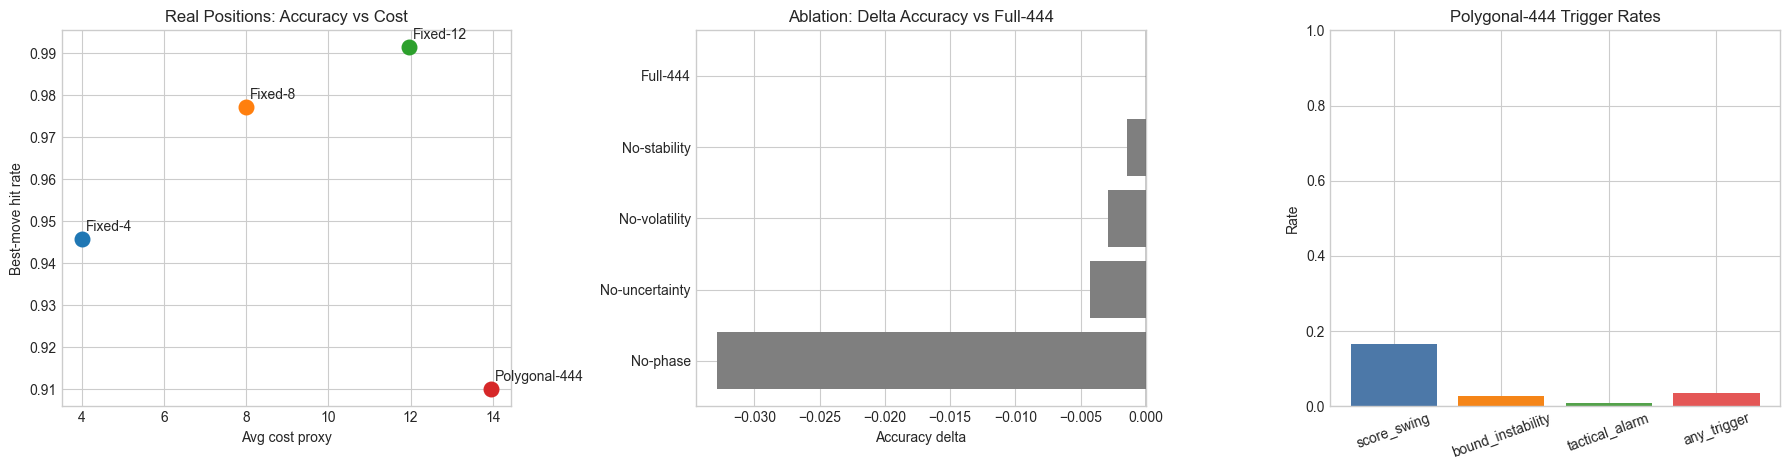

Real-position summary:


,strategy,accuracy,avg_cost,efficiency
1,Fixed-4,0.945714,4.000000,0.236429
2,Fixed-8,0.977143,7.990000,0.122296
0,Fixed-12,0.991429,11.967143,0.082846
3,Polygonal-444,0.910000,13.957371,0.065199



Ablation summary:


,variant,accuracy,avg_cost,mean_n0,trigger_rate,mean_edges,delta_acc_vs_full
1,No-phase,0.875714,7.804986,6.125714,0.077143,9.404286,-0.032857
3,No-uncertainty,0.904286,12.220114,9.265714,0.051429,20.072857,-0.004286
4,No-volatility,0.905714,11.683657,8.828571,0.044286,19.924286,-0.002857
2,No-stability,0.907143,13.390857,9.964286,0.041429,24.228571,-0.001429
0,Full-444,0.908571,13.957371,10.281429,0.035714,26.552857,0.000000



Polygonal trigger rates:
score_swing: 0.166
bound_instability: 0.027
tactical_alarm: 0.009
any_trigger: 0.036


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Real-position strategy comparison
ax = axes[0]
for _, r in real_summary.iterrows():
    ax.scatter(r['avg_cost'], r['accuracy'], s=110)
    ax.text(r['avg_cost'] + 0.10, r['accuracy'] + 0.002, r['strategy'])
ax.set_title('Real Positions: Accuracy vs Cost')
ax.set_xlabel('Avg cost proxy')
ax.set_ylabel('Best-move hit rate')

# Ablation delta accuracy
ax = axes[1]
plot_df = ab_summary.sort_values('delta_acc_vs_full')
colors = ['tab:gray' if v != 'Full-444' else 'tab:green' for v in plot_df['variant']]
ax.barh(plot_df['variant'], plot_df['delta_acc_vs_full'], color=colors)
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title('Ablation: Delta Accuracy vs Full-444')
ax.set_xlabel('Accuracy delta')

# Trigger diagnostics (Polygonal only)
ax = axes[2]
poly_only = real_df[real_df['strategy'] == 'Polygonal-444']
trigger_rates = {
    'score_swing': float(poly_only['score_swing_trigger'].mean()),
    'bound_instability': float(poly_only['bound_instability_trigger'].mean()),
    'tactical_alarm': float(poly_only['tactical_alarm_trigger'].mean()),
    'any_trigger': float(poly_only['trigger_fire'].mean()),
}
ax.bar(trigger_rates.keys(), trigger_rates.values(), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
ax.set_ylim(0.0, 1.0)
ax.set_title('Polygonal-444 Trigger Rates')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Real-position summary:')
display(real_summary)
print('\nAblation summary:')
display(ab_summary.sort_values('delta_acc_vs_full', ascending=True))

print('\nPolygonal trigger rates:')
for k, v in trigger_rates.items():
    print(f'{k}: {v:.3f}')